In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("smartcart_customers (1).csv")

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [7]:
df.shape

(2240, 22)

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

#DATA PREPROCESSING

In [9]:
#handling missing data
df["Income"]= df["Income"].fillna(df["Income"].median())

In [10]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

#feature engineering


In [11]:
df["age"] = 2026-df["Year_Birth"]

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [13]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)
ref_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"]= (ref_date-df["Dt_Customer"]).dt.days

In [14]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'Customer_Tenure_Days'],
      dtype='object')

In [15]:
#spending
df["Total_Spending"] = df["MntWines"]+ df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

In [16]:
#children
df["Total_Children"] = df["Kidhome"]+df["Teenhome"]

In [17]:
df["Education"].value_counts()
#graduate, under_graduate, post_graduate
df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate", "2n Cycle":"Undergraduate", 
    "Graduation":"Graduate",
    "PhD":"Postgraduate", "Master":"Postgraduate"
}
                       )
    


In [18]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [19]:
df["Living_With"]= df["Marital_Status"].replace({
    "Married":"Partner", "Together":"Partner", 
    "Single ":"Alone",
    "Divorced":"Alone", "Widow":"Alone", "Absurd":"Alone", "YOLO":"Alone"  
}
                                              )

                       

In [20]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds'] 

In [21]:
cols_to_drop = cols+spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

In [22]:
df_cleaned.shape

(2240, 15)

In [23]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1789,0,Single
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,29,2,Single
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,887,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,63,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,468,1,Partner


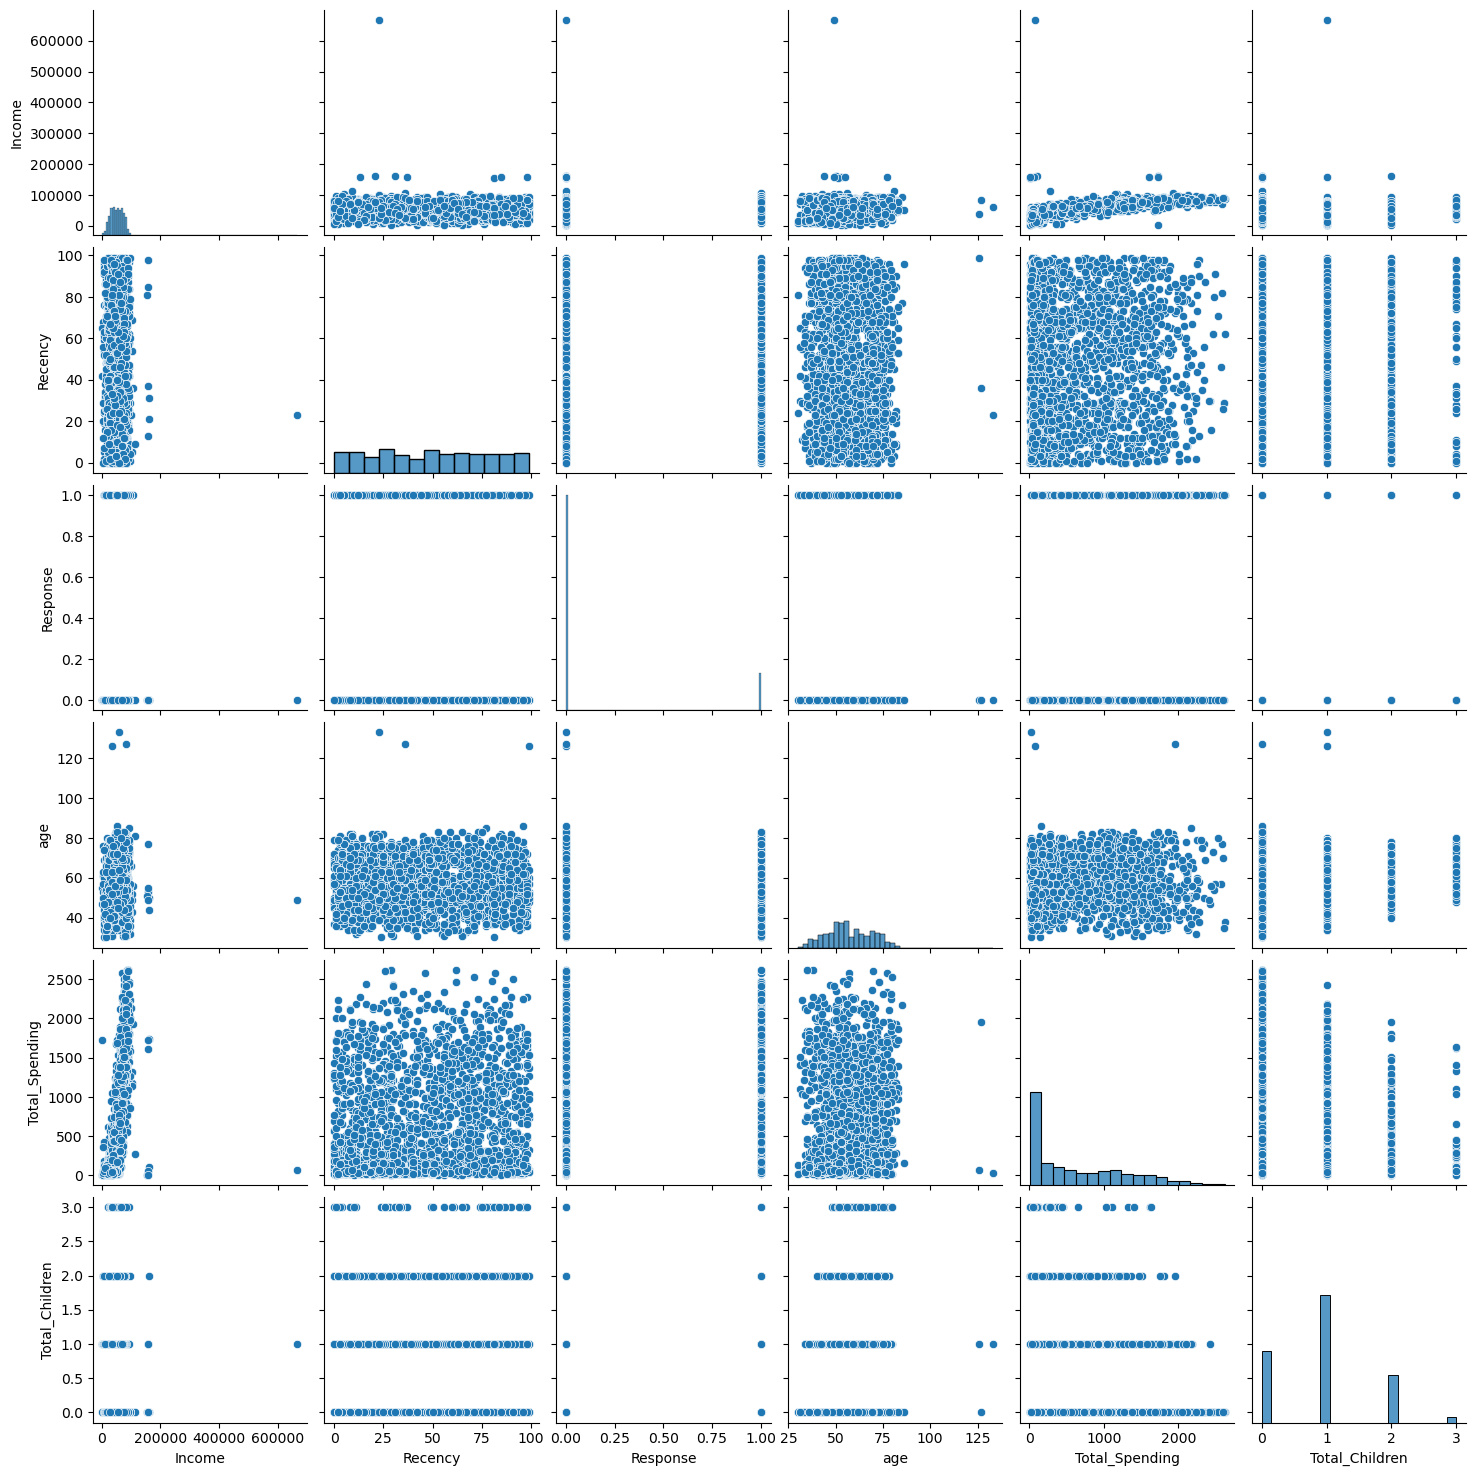

In [24]:
cols = ["Income", "Recency","Response","age", "Total_Spending","Total_Children"]
sns.pairplot(df_cleaned[cols])

In [72]:
print("data_size_for_outliers:", len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<60_000)] 
print("data_size_for_non_outliers:", len(df_cleaned))

data_size_for_outliers: 1397
data_size_for_non_outliers: 1397


In [73]:
print("data_size_for_outliers:", len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<60_000)] 
print("data_size_for_non_outliers:", len(df_cleaned))

data_size_for_outliers: 1397
data_size_for_non_outliers: 1397


In [27]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

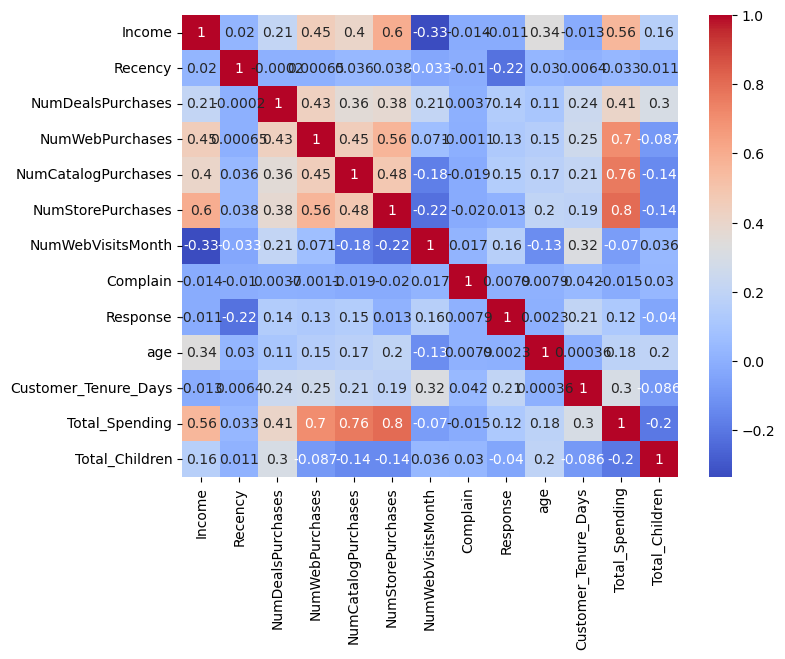

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

In [29]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1789,0,Single
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,29,2,Single
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,63,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,468,1,Partner
6,Graduate,55635.0,34,4,7,3,7,6,0,0,55,593,640,1,Alone


In [30]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
ohe = OneHotEncoder()
cat_cols = ["Education", "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [32]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [33]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Living_With_Single
0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0
6,1.0,0.0,0.0,1.0,0.0,0.0


In [34]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [35]:
df_encoded.shape

(1397, 19)

In [36]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Living_With_Single
0,58138.0,58,3,8,10,4,7,0,1,69,663,1789,0,1.0,0.0,0.0,0.0,0.0,1.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,29,2,1.0,0.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,63,1,1.0,0.0,0.0,0.0,1.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,468,1,0.0,1.0,0.0,0.0,1.0,0.0
6,55635.0,34,4,7,3,7,6,0,0,55,593,640,1,1.0,0.0,0.0,1.0,0.0,0.0


In [37]:
x = df_encoded

In [38]:
from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()
x_scaled = scaler.fit_transform(x)

In [39]:
x_scaled.shape

(1397, 19)

In [40]:
#2d
from sklearn.decomposition import PCA


In [41]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

Text(0.5, 0.92, '3d_projection')

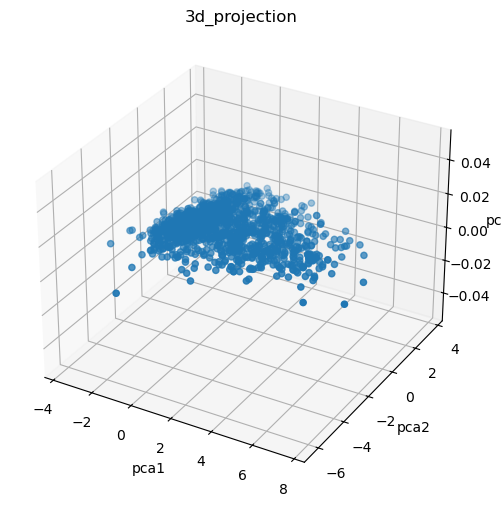

In [42]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:,0], x_pca[:,1])
ax.set_xlabel('pca1')
ax.set_ylabel('pca2')
ax.set_zlabel('pca3')
ax.set_title("3d_projection")

In [43]:
pca.explained_variance_ratio_

array([0.20317873, 0.10269873])

ANALYZE K VALUE
1. ELBOW METHOD

In [44]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [45]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
k_optimal = knee.elbow

In [46]:
print("best k", k_optimal)

best k 3


Text(0.5, 1.0, 'elbow_method')

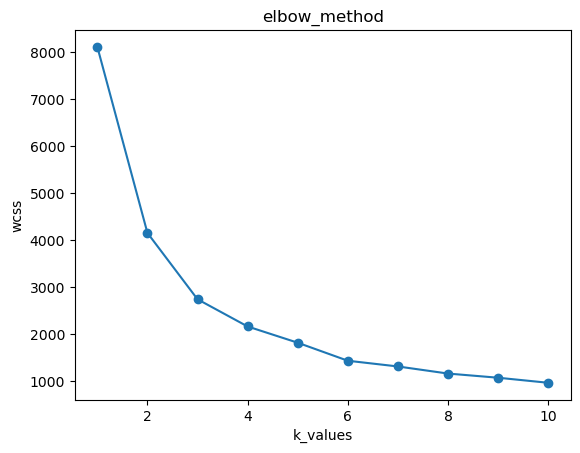

In [47]:
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("k_values")
plt.ylabel("wcss")
plt.title("elbow_method")

2. silhouette score
   

Text(0.5, 1.0, 'elbow_method')

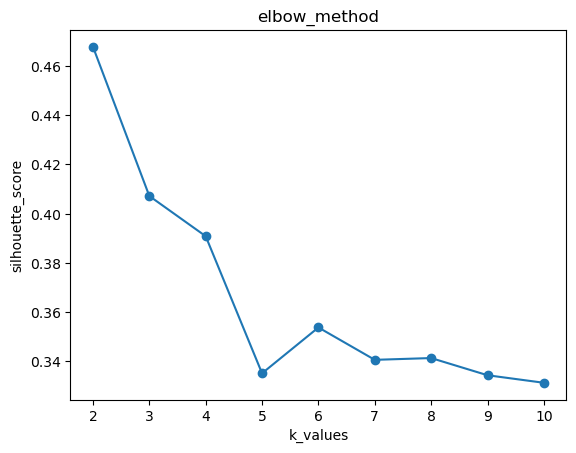

In [48]:
from sklearn.metrics import silhouette_score
scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca, labels)
    scores.append(score)
plt.plot(range(2,11), scores, marker="o")
plt.xlabel("k_values")
plt.ylabel("silhouette_score")
plt.title("elbow_method")

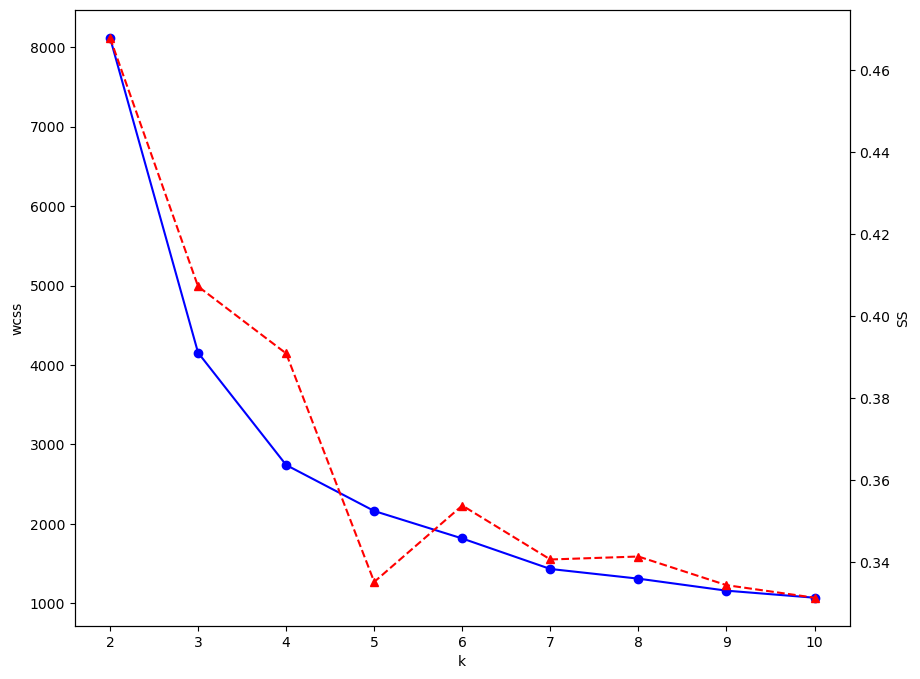

In [49]:
#combined plot
k_range = range(2,11)
fig, ax1 = plt.subplots(figsize=(10,8))
ax1.plot(list(k_range), wcss[:9], marker="o", color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(list(k_range), scores[:9], marker="^", color="red", linestyle="--")
ax2.set_ylabel("SS")
plt.show()

In [50]:
print(len(k_range))
print(len(scores))
print(len(wcss))

9
9
10


#CLUSTERING

In [51]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(x_pca)

Text(0.5, 0.92, '3d_projection')

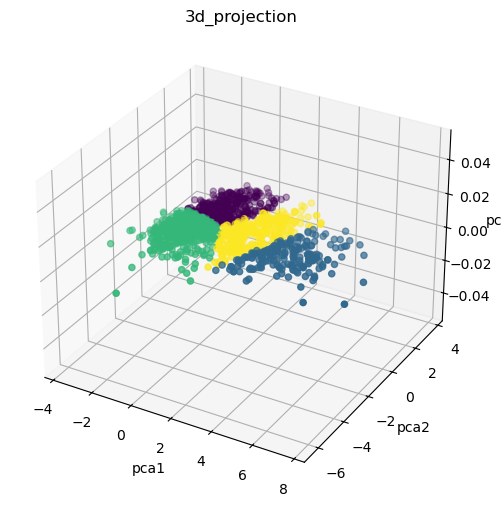

In [52]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:,0], x_pca[:,1], c = labels_kmeans)
ax.set_xlabel('pca1')
ax.set_ylabel('pca2')
ax.set_zlabel('pca3')
ax.set_title("3d_projection")

Text(0.5, 0.92, '3d_projection')

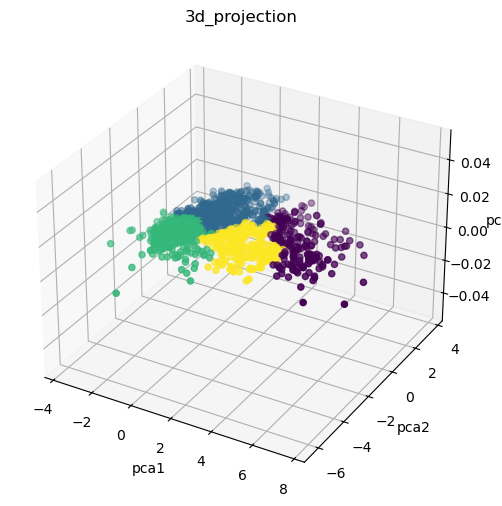

In [53]:
from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(x_pca)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:,0], x_pca[:,1], c = labels_agg)
ax.set_xlabel('pca1')
ax.set_ylabel('pca2')
ax.set_zlabel('pca3')
ax.set_title("3d_projection")

In [65]:
df_cleaned.drop("labels", axis=1)
x["clusters"]= labels_agg

In [66]:
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Living_With_Single,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1789,0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,46344.0,38,2,1,1,2,5,0,0,72,113,29,2,1.0,0.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,63,1,1.0,0.0,0.0,0.0,1.0,0.0,2
4,58293.0,94,5,5,3,6,5,0,0,45,161,468,1,0.0,1.0,0.0,0.0,1.0,0.0,0
6,55635.0,34,4,7,3,7,6,0,0,55,593,640,1,1.0,0.0,0.0,1.0,0.0,0.0,3


<Axes: xlabel='clusters', ylabel='count'>

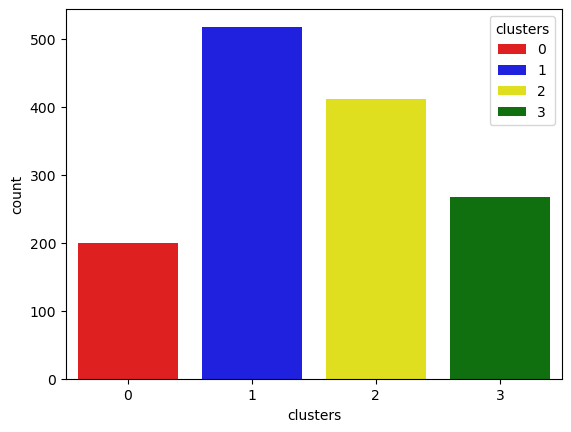

In [67]:
pal =["red", "blue", "yellow", "green"]
sns.countplot(x=x["clusters"], palette= pal, hue=x["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

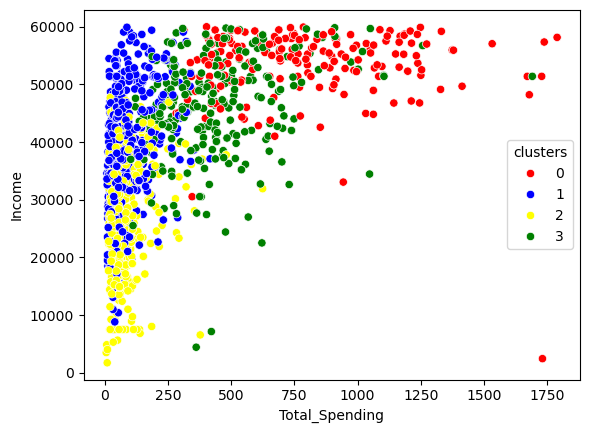

In [68]:
sns.scatterplot(x=x["Total_Spending"], y=x["Income"], hue=x["clusters"], palette=pal)

In [69]:
cluster_summary= x.groupby("clusters").mean()
print(cluster_summary)


                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         53317.537688  52.336683           4.180905         6.447236   
1         38446.839768  50.646718           1.849421         1.930502   
2         26621.075243  47.145631           1.987864         1.898058   
3         46029.738806  47.145522           3.802239         5.388060   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    3.763819           8.040201           5.894472  0.005025   
1                    0.505792           3.283784           5.799228  0.003861   
2                    0.383495           2.837379           7.376214  0.024272   
3                    1.839552           5.511194           6.559701  0.007463   

          Response        age  Customer_Tenure_Days  Total_Spending  \
clu